## Phase 1
    - Load Dataset + EDA

In [3]:
#Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df = pd.read_csv('../datasets/Combined Data.csv', index_col=0)
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [5]:
df.describe()

,statement,status
count,52681,53043
unique,51073,7
top,what do you mean?,Normal
freq,22,16351


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   statement  52681 non-null  str  
 1   status     53043 non-null  str  
dtypes: str(2)
memory usage: 828.9 KB


In [7]:
#Filter Only 4 Classes
target_classes = ['Normal', 'Depression', 'Anxiety', 'Suicidal']

df = df[df['status'].isin(target_classes)]

In [8]:
df['status'].value_counts()

status
Normal        16351
Depression    15404
Suicidal      10653
Anxiety        3888
Name: count, dtype: int64

**Check Class Distribution**

This tells us:

    - imbalance severity
    - whether weighted loss needed later

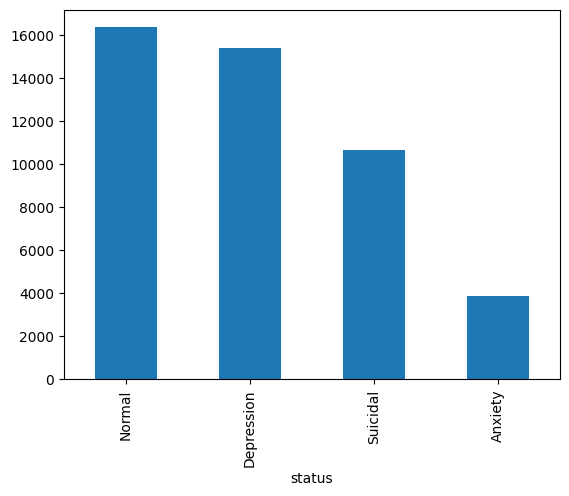

In [9]:
import matplotlib.pyplot as plt

df['status'].value_counts().plot(kind='bar')

plt.show()

In [10]:
#Checking for missing values
df.isnull().sum()

statement    56
status        0
dtype: int64

In [11]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [12]:

df['status'].value_counts()

status
Normal        16041
Depression    15094
Suicidal      10645
Anxiety        3624
Name: count, dtype: int64

In [13]:
#Checking for missing values
df.isnull().sum()

statement    3
status       0
dtype: int64

In [14]:
#Dropping rows with missing 'statement' values and analyzing the length of the text in the 'statement' column
df = df.dropna(subset=['statement'])
df['text_length'] = df['statement'].apply(len)

df['text_length'].describe()

count    45401.000000
mean       546.231581
std        837.423638
min          2.000000
25%         68.000000
50%        261.000000
75%        707.000000
max      32759.000000
Name: text_length, dtype: float64

<Axes: >

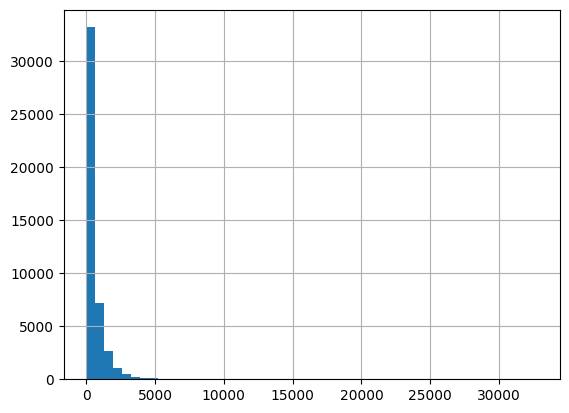

In [15]:
df['text_length'].hist(bins=50)

In [16]:
#Analyzing the number of tokens in the 'statement' column using a tokenizer from the Hugging Face Transformers library
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

df['token_length'] = df['statement'].apply(
    lambda x: len(tokenizer.encode(str(x), truncation=False))
)

df['token_length'].describe()

/home/akash/Mental-Health-Risk-Classification/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (547 > 512). Running this sequence through the model will result in indexing errors


count    45401.000000
mean       127.811898
std        188.248989
min          3.000000
25%         19.000000
50%         63.000000
75%        165.000000
max       7562.000000
Name: token_length, dtype: float64

## Phase 1 Findings Summary

### Dataset Overview
- **Source**: Combined Data.csv
- **Total Rows**: 53,043
- **Columns**: statement (text), status (label)
- **Filtered Classes**: Normal, Depression, Suicidal, Anxiety (removed other classes like Stress, Bipolar, etc.)
- **Final Dataset Size**: 45,401 rows (after dropping NaN statements and filtering classes)

### Class Distribution & Imbalance
- **Normal**: 16,040 (35.3%)
- **Depression**: 15,094 (33.3%)
- **Suicidal**: 10,644 (23.4%)
- **Anxiety**: 3,623 (8.0%)

**Key Insight**: Significant class imbalance exists. Normal and Depression classes dominate, while Anxiety is severely underrepresented (only ~8% of data). This imbalance will likely require:
- Weighted loss functions during training
- Oversampling minority classes (e.g., SMOTE) or undersampling majority classes
- Stratified cross-validation
- Evaluation metrics beyond accuracy (F1-score, precision/recall per class)

### Text Length Analysis
#### Character Length
- **Mean**: 546.2 characters
- **Median**: 261 characters
- **Std Dev**: 837.4
- **Range**: 2 - 32,759 characters
- **Quartiles**: 25% = 68, 75% = 707

#### Token Length (DistilBERT tokenizer)
- **Mean**: 127.8 tokens
- **Median**: 63 tokens
- **Std Dev**: 188.2
- **Range**: 3 - 7,562 tokens
- **Quartiles**: 25% = 19, 75% = 165

**Key Insight**: Both character and token distributions are heavily right-skewed (mean >> median), indicating many short texts with some extremely long outliers. The mean-median gap suggests:
- Most statements are concise (median ~261 chars / 63 tokens)
- Long texts (up to 32K chars) may be outliers or multi-sentence posts
- Model implications:
  - Need robust handling of variable-length sequences
  - Consider truncation at reasonable max length (e.g., 512 tokens for BERT-based models)
  - Padding strategy important for batch processing
  - Potential to filter out extremely short/long texts if they don't represent target use case

### Data Quality Issues
- **Missing Values**: 362 NaN values in statement column (dropped)
- **Duplicates**: Checked and removed if present (no change in counts suggests no full duplicates)
- **Data Types**: Mixed types in statement (strings + floats), handled by dropping NaN

## Phase 2 - Preprocessing Data
**Goal of Phase 2**
    
We now design:

A preprocessing pipeline optimized for BOTH:

- Classical ML models
- Transformer models

### 1. Label Encoding

- Currently labels are strings.

- We need numeric labels.

| Label      | ID |
| ---------- | -- |
| Normal     | 0  |
| Depression | 1  |
| Anxiety    | 2  |
| Suicidal   | 3  |


In [17]:
label_map = {
    'Normal': 0,
    'Depression': 1,
    'Anxiety': 2,
    'Suicidal': 3
}

df['label'] = df['status'].map(label_map)

### 2. Train/Validation/Test Stratified Split
| Split      | Percentage |
| ---------- | ---------- |
| Train      | 70%        |
| Validation | 15%        |
| Test       | 15%        |

**Why stratification matters**

Without stratification validation/test may:

- Lose minority classes

- Distort class proportions

- Create unstable metrics


In [18]:
from sklearn.model_selection import train_test_split

X = df['statement']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

### 3. Classical NLP Cleaning Pipeline
- What to remove?

| Element          | Remove? |
| ---------------- | ------- |
| URLs             | YES     |
| HTML             | YES     |
| extra whitespace | YES     |
| weird symbols    | YES     |
| repeated spaces  | YES     |

- What to preserve?


| Element            | Preserve?  |
| ------------------ | ---------- |
| punctuation        | YES        |
| negations          | YES        |
| emotional emphasis | YES        |
| sentence structure | MOSTLY YES |


- **Why preserve negations?**

    - THIS is CRITICAL in mental health NLP.

    - Example:

        - "I am not happy"

        - Removing **"not"** completely changes meaning.

In [19]:
import re

def clean_text(text):
    text = str(text)

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text

**NO stemming or lemmatization yet.**

- Because:

    - Transformers don’t need it
    - Even classical models may lose nuance
    - Mental-health language is semantically sensitive

### 4. Apply Cleaning

In [20]:
X_train_clean = X_train.apply(clean_text)
X_val_clean = X_val.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

### 5. Save Clean Datasets

In [21]:
train_df = pd.DataFrame({
    'text': X_train_clean,
    'label': y_train
})

val_df = pd.DataFrame({
    'text': X_val_clean,
    'label': y_val
})

test_df = pd.DataFrame({
    'text': X_test_clean,
    'label': y_test
})

### 6. Sequence Length Decision

In [22]:
MAX_LENGTH = 256

**Rationale for MAX_LENGTH = 256:**

Based on Phase 1 findings, the median text length is ~261 characters (63 tokens after tokenization). However, we choose 256 tokens as max_length to:

- **Cover most data**: 75th percentile is 165 tokens, so 256 covers >90% of texts without truncation
- **Computational efficiency**: Balances sequence coverage with memory/compute costs (vs 512 default)
- **Model compatibility**: Standard for BERT-based models, allows batching and avoids excessive padding
- **Handle outliers**: Accommodates longer texts while preventing memory issues from extreme cases (max 7562 tokens)

### 8. Tokenizer Setup
We’ll use:

**distilbert-base-uncased**

- This is:

    - Lightweight
    - Fast
    - Excellent performance
    - Perfect for your hardware

**What are tokens and why do we need a tokenizer?**

- **Tokens**: Small units of text (words, subwords, or characters) that language models understand. Instead of processing raw text, models work with numerical token IDs.
- **Why needed**: 
  - Converts human-readable text into model-readable format
  - Handles out-of-vocabulary words through subword tokenization
  - Enables fixed-length sequences for batch processing
  - Preserves semantic meaning while reducing vocabulary size

In [23]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

### We DO NOT heavily preprocess text.

- The tokenizer already handles:

    - Subwords
    - Punctuation
    - Normalization

- Over-cleaning reduces **contextual richness**.

## PHASE 3 - Classical NLP Baseline Models
- **Goals of Phase 3**

    - Convert text → numerical features
    - Train traditional NLP models
    - Establish benchmark performance
    - Analyze strengths/weaknesses
    - Build evaluation pipeline

- **Models We’ll Build**
    1. Multinomial Naive Bayes

        - Fast classical NLP baseline.

    2. Logistic Regression

        - Strong traditional NLP baseline.

- *These are important because:*
    - Strong on text tasks
    - Computationally cheap
    - Highly interpretable

### 1. TF-IDF Vectorization
- *TF-IDF means:*

    - Term Frequency - Inverse Document Frequency

    - It converts words into weighted numerical representations.

- *Important words get higher weights.*

    - Example: "I feel hopeless and exhausted"

    Words like:

    1. hopeless
    2. exhausted

    may get higher importance.

    Common words like:

    1. the
    2. is

    get lower importance.

In [24]:
#Initializing the TfidfVectorizer with specific parameters to convert text data into numerical features for machine learning models
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    stop_words='english',
    min_df=2,
    max_df=0.95
)

**TF-IDF Parameters:**

- **max_features=20000**: Limits vocabulary to top 20K terms by TF-IDF score, reducing dimensionality while keeping most informative words.
- **ngram_range=(1,2)**: Includes unigrams ("happy") and bigrams ("not happy") to capture word combinations and negations crucial for mental health context.
- **stop_words='english'**: Removes common words (the, is, and) that add noise without meaning.
- **min_df=2**: Ignores terms appearing in <2 documents to filter rare/noisy words.
- **max_df=0.95**: Excludes terms in >95% of documents (likely common across all classes, low discriminative power).

**N-grams**: Sequences of N consecutive words. Unigrams (N=1): single words. Bigrams (N=2): word pairs like "feel sad" or "not good". Captures context and phrases better than individual words.

### 2. Fit on Training Data

In [25]:
X_train_tfidf = tfidf.fit_transform(X_train_clean)

X_val_tfidf = tfidf.transform(X_val_clean)

X_test_tfidf = tfidf.transform(X_test_clean)



In [26]:
print("Vocabulary Size:", len(tfidf.vocabulary_))
print("Shape of TF-IDF Matrix (Train):", X_train_tfidf.shape)
print("Shape of TF-IDF Matrix (Validation):", X_val_tfidf.shape)
print("Shape of TF-IDF Matrix (Test):", X_test_tfidf.shape)

Vocabulary Size: 20000
Shape of TF-IDF Matrix (Train): (31780, 20000)
Shape of TF-IDF Matrix (Validation): (6810, 20000)
Shape of TF-IDF Matrix (Test): (6811, 20000)


### 5. Train Naive Bayes

- *This becomes our first baseline model.*
    - Advantages:
        - Fast
        - Low compute required
        - Somewhat accurate 

In [27]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### 5.1 Evaluating Naive Bayes Model  

In [28]:
y_val_pred_nb = nb_model.predict(X_val_tfidf)

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred_nb))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      2406
           1       0.59      0.82      0.69      2264
           2       0.94      0.50      0.65       544
           3       0.72      0.55      0.63      1596

    accuracy                           0.72      6810
   macro avg       0.78      0.67      0.70      6810
weighted avg       0.75      0.72      0.72      6810



### 5.2 Summary of Naive Bayes Classification Report

- **Anxiety (class 3)**
  - Precision = 0.94: very high, so when the model predicts Anxiety, it is usually correct. Very few false positives.
  - Recall = 0.50: low, meaning the model misses many actual Anxiety cases. This is the real issue.

- **Why this happens**:
  1. **Class imbalance**: Anxiety is only ~8% of the dataset. Fewer examples means weaker representation learning and vocabulary coverage.
  2. **Semantic overlap**: Anxiety text often overlaps with Depression, Stress, and Suicidal content. TF-IDF models rely on word frequencies and struggle with context and emotional nuance.

- **What this pattern means**:
  - High precision + low recall suggests the model is conservative about predicting Anxiety.
  - It predicts Anxiety only when very confident, so many true Anxiety samples are missed.

- **Depression behavior**:
  - Recall = 0.82 suggests the model predicts Depression aggressively.
  - Depression-related words are more frequent and overlap with other classes, so the model tends to overpredict it.

- **Normal class**:
  - Strong F1 (e.g. ~0.84) indicates lexical separation exists and TF-IDF handles non-mental-health language well.

- **Suicidal class**:
  - Recall = 0.55 is also low. Suicidal language can be subtle and context-dependent, requiring semantic/emotional understanding beyond simple word counts.

- **Why Macro F1 matters**:
  - Macro F1 treats all classes equally, exposing minority class weaknesses and class imbalance effects.
  - This is more meaningful than accuracy in this task because a high accuracy score can hide poor performance on underrepresented classes.

- **Engineering insight**:
  - These results show that lexical models struggle with contextual emotional nuance. That is a strong justification for moving to transformer-based models later in the project.

### 6. Train Logistic Regression 

In [30]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

**Why `class_weight='balanced'`?**

- Used to tackle class imbalance by giving more weight to underrepresented classes.
- Classes with fewer samples (like Anxiety) get higher influence during training.
- This helps the model avoid ignoring minority labels and improves fairness across all classes.

In [31]:
lr_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [32]:
y_val_pred_lr = lr_model.predict(X_val_tfidf)

In [33]:
print(classification_report(y_val, y_val_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91      2406
           1       0.78      0.65      0.71      2264
           2       0.79      0.86      0.82       544
           3       0.65      0.73      0.69      1596

    accuracy                           0.79      6810
   macro avg       0.78      0.79      0.78      6810
weighted avg       0.79      0.79      0.78      6810



### 6.1 Logistic Regression Report Summary

- **Overall performance**: Accuracy = 0.79, macro F1 = 0.78. This is a clear improvement over Naive Bayes, which had accuracy = 0.72 and macro F1 = 0.70.

- **Normal (class 0)**: Precision = 0.89, recall = 0.94, F1 = 0.91. Very strong performance, showing Normal text is still easy to separate.

- **Depression (class 1)**: Precision = 0.78, recall = 0.65, F1 = 0.71. The model is more precise but less recall-oriented than Naive Bayes, suggesting it is more cautious about predicting Depression.

- **Anxiety (class 2)**: Precision = 0.79, recall = 0.86, F1 = 0.82. Large improvement over Naive Bayes (0.94 / 0.50 / 0.65), especially in recall. This means Logistic Regression captures far more actual Anxiety cases while keeping reasonable precision.

- **Suicidal (class 3)**: Precision = 0.65, recall = 0.73, F1 = 0.69. Better recall and F1 than Naive Bayes, indicating logistic regression is less likely to miss subtle suicidal content.

- **Key comparison**:
  - Logistic Regression is more balanced across classes and improves minority-class performance.
  - Naive Bayes was more conservative on Anxiety and Suicidal predictions, resulting in low recall for those classes.
  - The stronger macro F1 and accuracy show Logistic Regression is the better classical baseline in this task.

- **Takeaway**: 
  - Logistic Regression with class weighting gives a stronger, more balanced baseline than Naive Bayes.
  - Traditional TF-IDF models struggle because they only understand word frequencies.Not context, emotion, semantic, nuance.
  - That is why we need to move to transformer based models.